In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline

import joblib

from IPython.display import display

In [6]:
# read data
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

display("X shape:", X.shape)
display("y shape:", y.shape)

display(X.head())
# display(y.head())

'X shape:'

(569, 30)

'y shape:'

(569,)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
display(data.target_names)
display(y.value_counts())

array(['malignant', 'benign'], dtype='<U9')

1    357
0    212
Name: target, dtype: int64

In [9]:
#Basic EDA
display("Shape:", X.shape)

display("\nColumns:")
display(X.columns.tolist())

display("\nData types:")
display(X.dtypes)

display("\nDataset information:")
X.info()

'Shape:'

(569, 30)

'\nColumns:'

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension']

'\nData types:'

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

'\nDataset information:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [10]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [11]:
# Missing Value Check
missing_values = X.isnull().sum()

print("Total missing values:", missing_values.sum())

display(
    missing_values[
        missing_values > 0
    ].to_frame("Missing_Count")
)

Total missing values: 0


,Missing_Count


In [12]:
#Duplicate Check
display(
    "Duplicate rows:",
    X.duplicated().sum()
)


'Duplicate rows:'

0

1    357
0    212
Name: target, dtype: int64

'Percentage:'

1    62.741652
0    37.258348
Name: target, dtype: float64

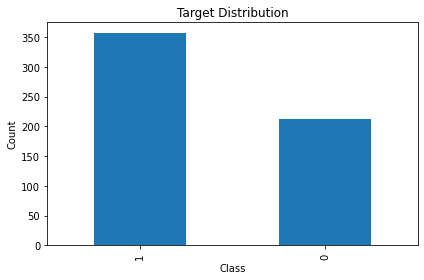

In [16]:
# Target Distribution
display(y.value_counts())

display("Percentage:")
display(
    y.value_counts(normalize=True) * 100
)

plt.figure(figsize=(6, 4))

y.value_counts().plot(
    kind="bar"
)

plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

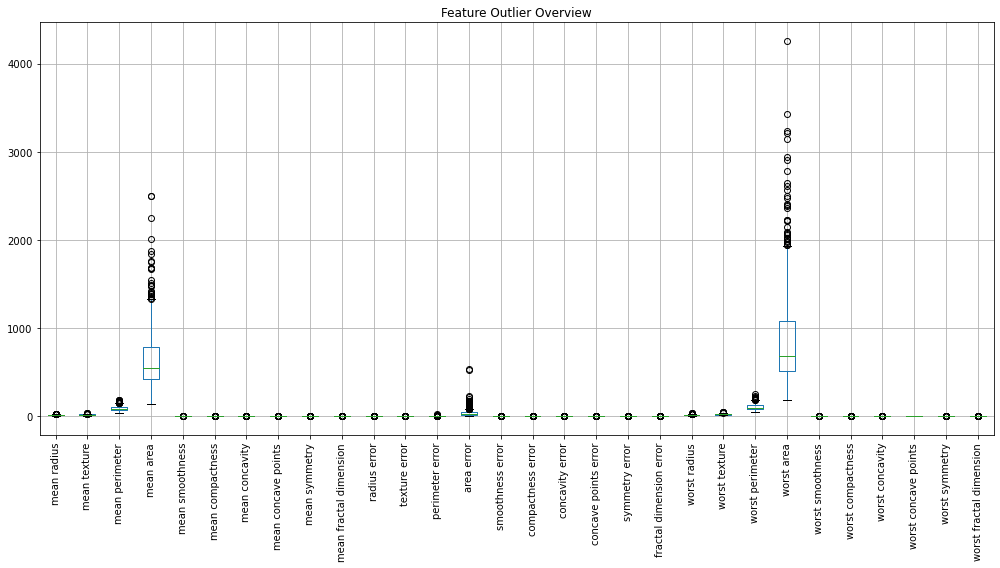

In [17]:
# Outlier Analysis

plt.figure(figsize=(14, 8))

X.boxplot()

plt.xticks(
    rotation=90
)

plt.title("Feature Outlier Overview")

plt.tight_layout()
plt.show()

# You may notice many potential outliers.
# But here's an important production lesson:
# Do not automatically delete every statistical outlier.
# We need domain knowledge before removing it.

In [19]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
# StandardScaler
pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=42
        )
    )
])

# The pipeline automatically:

# X_train
#    ↓
# StandardScaler
#    ↓
# MLPClassifier

# MLPClassifier gives us a feed-forward neural network for classification.

In [25]:
# MLPClassifier(
#     hidden_layer_sizes=(64, 32),
#     activation="relu",
#     random_state=42,
#     max_iter=1000
# )

# Input
#   ↓
# 64 neurons
#   ↓
# 32 neurons
#   ↓
# Output
# with ReLU activation in the hidden layers.

In [26]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                               random_state=42))])

In [28]:
predictions = pipeline.predict(X_test)
probabilities = pipeline.predict_proba(X_test)[:, 1]

In [32]:
print(
    "Accuracy:",
    accuracy_score(y_test, predictions)
)

print(
    "Precision:",
    precision_score(y_test, predictions)
)

print(
    "Recall:",
    recall_score(y_test, predictions)
)

print(
    "F1 Score:",
    f1_score(y_test, predictions)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, probabilities)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.9649122807017544
Precision: 0.9857142857142858
Recall: 0.9583333333333334
F1 Score: 0.971830985915493
ROC-AUC: 0.9937169312169312

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



[[41  1]
 [ 3 69]]


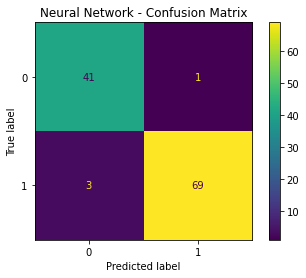

In [34]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Neural Network - Confusion Matrix")
plt.show()

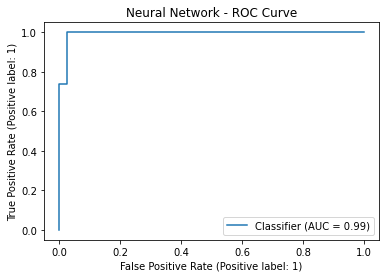

In [35]:
RocCurveDisplay.from_predictions(
    y_test,
    probabilities
)

plt.title("Neural Network - ROC Curve")
plt.show()

In [37]:
# Training Loss vs Validation Performance

# pipeline.named_steps["model"].loss_curve_

In [40]:
# check the loss curve:
model = pipeline.named_steps["model"]
loss_curve = model.loss_curve_

print(loss_curve)

[0.692880293828821, 0.5848104376291118, 0.4962515290092373, 0.4245326676365555, 0.36682758526433745, 0.31932970738723954, 0.28083854122735885, 0.2486285208391974, 0.22186108715760294, 0.19922221065356244, 0.18030126344591452, 0.1641960752397199, 0.15016346807034991, 0.13825005064465912, 0.12820196325673064, 0.11955596831494326, 0.1119363310039003, 0.10553066476273726, 0.09955017056725037, 0.09446142322264377, 0.08988967175013761, 0.08579546555750088, 0.08208278239526746, 0.07872349700190975, 0.07550572229680402, 0.07277136854875793, 0.07026510396414866, 0.06780297166675132, 0.06555657944487933, 0.06339422010508539, 0.06147104286256882, 0.05955691745562125, 0.057912360572384296, 0.056268353699110506, 0.05482878795586226, 0.053313208937309446, 0.052010282714698965, 0.05075431062519468, 0.04970337012463219, 0.048488998496464826, 0.04746561882317047, 0.04630823738576029, 0.045160873573132164, 0.04416986624314957, 0.043073114677704735, 0.04228408188328714, 0.04142615138450507, 0.04066865471

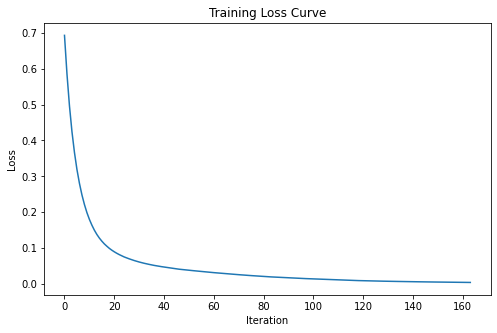

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(loss_curve)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()


#The loss generally decreases as training progresses.
#Loss curve: Loss tells the model:
# "How wrong was your prediction?"

In [ ]:
#Early Stopping
early_stopping=True
MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# Now the model can reserve part of the training data for validation and stop training when validation performance stops improving.

In [44]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        max_iter=1000,
        random_state=42
    ))
])

# grid serach:
param_grid = {
    "model__hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32)
    ],

    "model__activation": [
        "relu",
        "tanh"
    ],

    "model__alpha": [
        0.0001,
        0.001,
        0.01
    ],

    "model__learning_rate_init": [
        0.001,
        0.01
    ]
}

In [45]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [46]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        MLPClassifier(max_iter=1000,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'model__activation': ['relu', 'tanh'],
                         'model__alpha': [0.0001, 0.001, 0.01],
                         'model__hidden_layer_sizes': [(32,), (64,), (64, 32)],
                         'model__learning_rate_init': [0.001, 0.01]},
             scoring='f1', verbose=1)

In [49]:
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)
print(
    "Best CV Score:",
    grid_search.best_score_
)
best_model = grid_search.best_estimator_

print(best_model)

Best Parameters:
{'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (32,), 'model__learning_rate_init': 0.01}
Best CV Score: 0.986053018419313
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(32,),
                               learning_rate_init=0.01, max_iter=1000,
                               random_state=42))])


In [51]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            predictions
        )
    )

    print(
        "Precision:",
        precision_score(
            y_test,
            predictions
        )
    )

    print(
        "Recall:",
        recall_score(
            y_test,
            predictions
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_test,
            predictions
        )
    )

    print(
        "ROC-AUC:",
        roc_auc_score(
            y_test,
            probabilities
        )
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions
        )
    )

In [52]:
evaluate_model(
    best_model,
    X_test,
    y_test
)

Accuracy: 0.956140350877193
Precision: 0.9855072463768116
Recall: 0.9444444444444444
F1 Score: 0.9645390070921985
ROC-AUC: 0.9923941798941799

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [53]:
# Save the model:
joblib.dump(
    best_model,
    "diabetes_neural_network_pipeline.joblib"
)

# we're saving the entire pipeline, not just the neural network.
# StandardScaler
# +
# MLPClassifier

['diabetes_neural_network_pipeline.joblib']

In [55]:
# load the model:
loaded_model = joblib.load(
    "diabetes_neural_network_pipeline.joblib"
)